In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/yaml-human-object-detection-kp-internal/data.yaml
/kaggle/input/human-dataset/labels/val.cache
/kaggle/input/human-dataset/labels/train.cache
/kaggle/input/human-dataset/labels/val/82d7dfddbdfaf7da.txt
/kaggle/input/human-dataset/labels/val/5031cd3f7448de11.txt
/kaggle/input/human-dataset/labels/val/df0d7d38cab6b89e.txt
/kaggle/input/human-dataset/labels/val/afcc948ab19bb539.txt
/kaggle/input/human-dataset/labels/val/ccb99214a452d149.txt
/kaggle/input/human-dataset/labels/val/8c08952ef54c30bc.txt
/kaggle/input/human-dataset/labels/val/def2d58ff99771d9.txt
/kaggle/input/human-dataset/labels/val/f5916fd09e1ef41f.txt
/kaggle/input/human-dataset/labels/val/67fbfe0221fd45f6.txt
/kaggle/input/human-dataset/labels/val/bba4fb693949252e.txt
/kaggle/input/human-dataset/labels/val/6d6b9486b7fd578d.txt
/kaggle/input/human-dataset/labels/val/caad642daf5cca9d.txt
/kaggle/input/human-dataset/labels/val/80249b89da009d50.txt
/kaggle/input/human-dataset/labels/val/b6134e8d0646bb31.txt
/kag

# 0. Import Library

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 21.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.10.19
    Uninstalling nvidia-curand-cu12-10.3

In [3]:
import numpy as np
import pandas as pd
import os
import yaml
import glob
from PIL import Image as PILImage
import shutil
import torch
import cv2
import random
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from pathlib import Path
from IPython.display import display, Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
def check_device():
    return 'cuda' if torch.cuda.is_available() else 'cpu'
    
def load_yaml(yaml_path):
    with open(yaml_path, 'r') as f:
        return yaml.safe_load(f)

# 1. Data Loading

In [5]:
data_yaml_path = '/kaggle/input/yaml-human-object-detection-kp-internal/data.yaml' 
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

## Sample Images

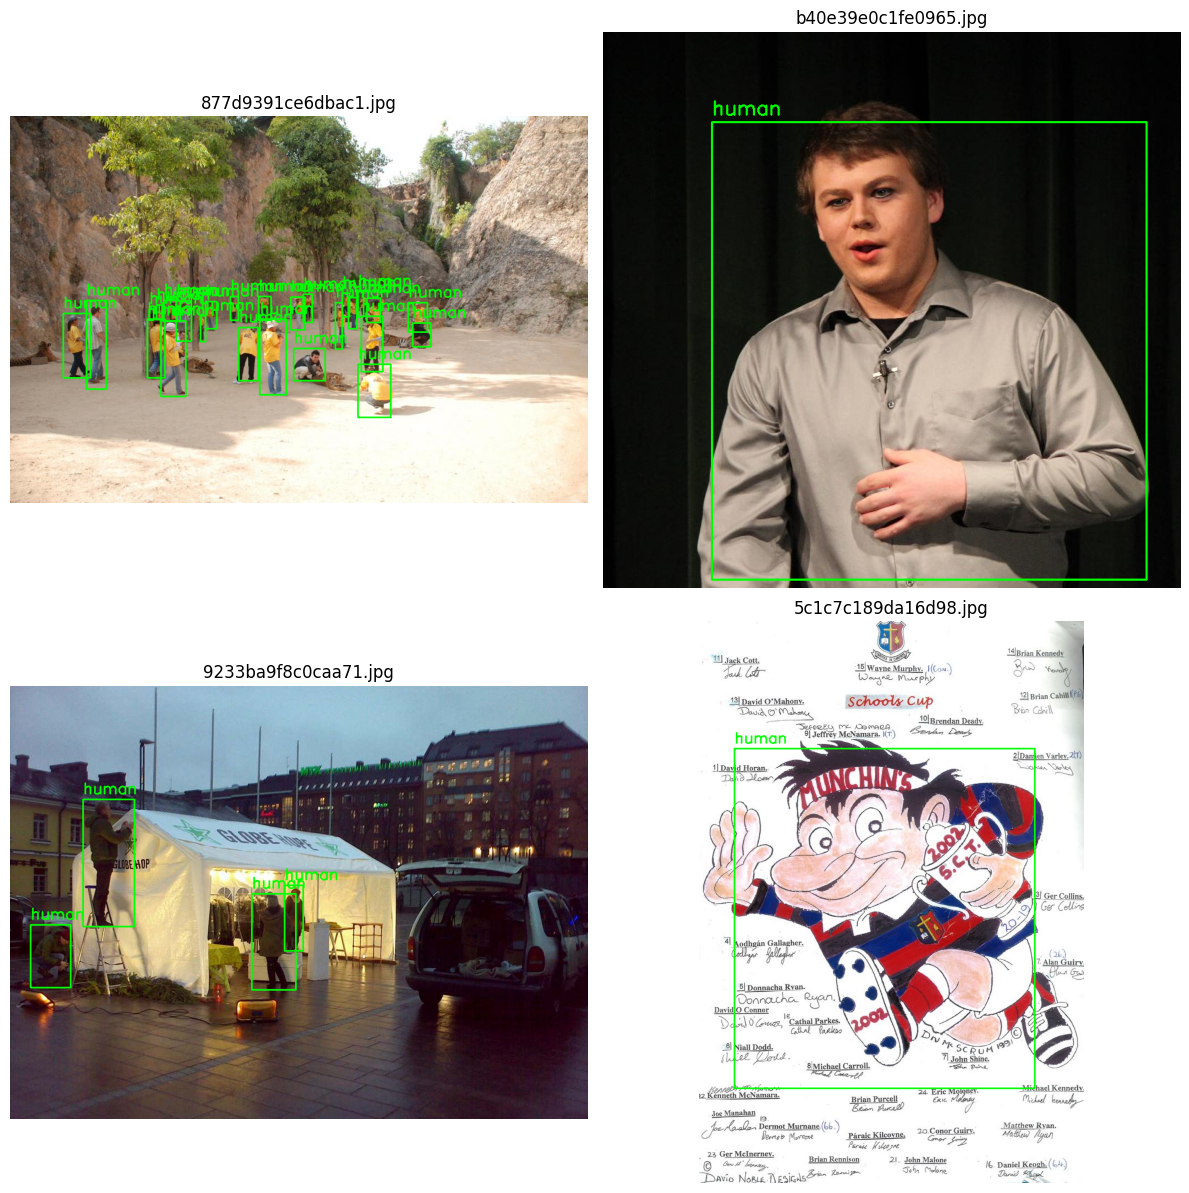

In [6]:
def display_sample_images(image_dir, label_dir, class_names, num_samples=4):
    image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    sample_images = random.sample(image_files, min(num_samples, len(image_files)))
    
    plt.figure(figsize=(12, 12))
    for i, image_name in enumerate(sample_images):
        image_path = os.path.join(image_dir, image_name)
        label_path = os.path.join(label_dir, os.path.splitext(image_name)[0] + '.txt')
        
        image = cv2.imread(image_path)
        h, w, _ = image.shape
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    class_id, x_center, y_center, width, height = map(float, line.split())
                    
                    x1 = int((x_center - width / 2) * w)
                    y1 = int((y_center - height / 2) * h)
                    x2 = int((x_center + width / 2) * w)
                    y2 = int((y_center + height / 2) * h)
                    
                    # Gambar bounding box
                    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    # Tambahkan label kelas
                    label = class_names[int(class_id)]
                    cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

        ax = plt.subplot(2, 2, i + 1)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title(image_name)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Tampilkan sampel
train_image_dir = data_config['train']
train_label_dir = train_image_dir.replace('images', 'labels')
display_sample_images(train_image_dir, train_label_dir, data_config['names'])

# 2. Train model

In [7]:
# Memuat model YOLOv8m pre-trained
device = check_device()
model = YOLO("yolov8m.pt").to(device)

# Melatih model
results = model.train(
    data=data_yaml_path, 
    epochs=35, 
    imgsz=640, 
    project='YOLOv8m-Detection', 
    name='train_results'
)

100%|██████████| 49.7M/49.7M [00:00<00:00, 220MB/s]


engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/yaml-human-object-detection-kp-internal/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train_results, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=YOLOv8m-De

100%|██████████| 755k/755k [00:00<00:00, 17.2MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 75.3MB/s]


...

                   all       4000      16377      0.672      0.595       0.64      0.377

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      35/35      7.74G      1.194     0.8703      1.313         37        640: 100%|██████████| 860/860 [08:52<00:00,  1.61it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 125/125 [00:42<00:00,  2.92it/s]


                   all       4000      16377      0.663        0.6       0.64      0.377

35 epochs completed in 5.624 hours.
Optimizer stripped from YOLOv8m-Detection/train_results/weights/last.pt, 52.0MB
Optimizer stripped from YOLOv8m-Detection/train_results/weights/best.pt, 52.0MB

Validating YOLOv8m-Detection/train_results/weights/best.pt...
Ultralytics 8.3.168 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 125/125 [00:45<00:00,  2.76it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       4000      16377      0.663        0.6      0.641      0.377
Speed: 0.1ms preprocess, 7.5ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to YOLOv8m-Detection/train_results


# 3. Evaluation

In [8]:
metrics = model.val()

Ultralytics 8.3.168 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 588.4±259.2 MB/s, size: 287.1 KB)


val: Scanning /kaggle/input/human-dataset/labels/val... 4000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4000/4000 [00:06<00:00, 653.41it/s]


WARNING ⚠️ val: Cache directory /kaggle/input/human-dataset/labels is not writeable, cache not saved.


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 250/250 [00:45<00:00,  5.51it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       4000      16377      0.667      0.596      0.641      0.378
Speed: 0.2ms preprocess, 7.8ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to YOLOv8m-Detection/train_results2


In [9]:
map_50 = metrics.box.map50
map_50_95 = metrics.box.map
precision = metrics.box.mp
recall = metrics.box.mr

print(f"mAP@0.5: {map_50:.2%}")
print(f"mAP@0.5:0.95: {map_50_95:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

mAP@0.5: 64.06%
mAP@0.5:0.95: 37.79%
Precision: 66.73%
Recall: 59.61%


# 4. Visualizing Results

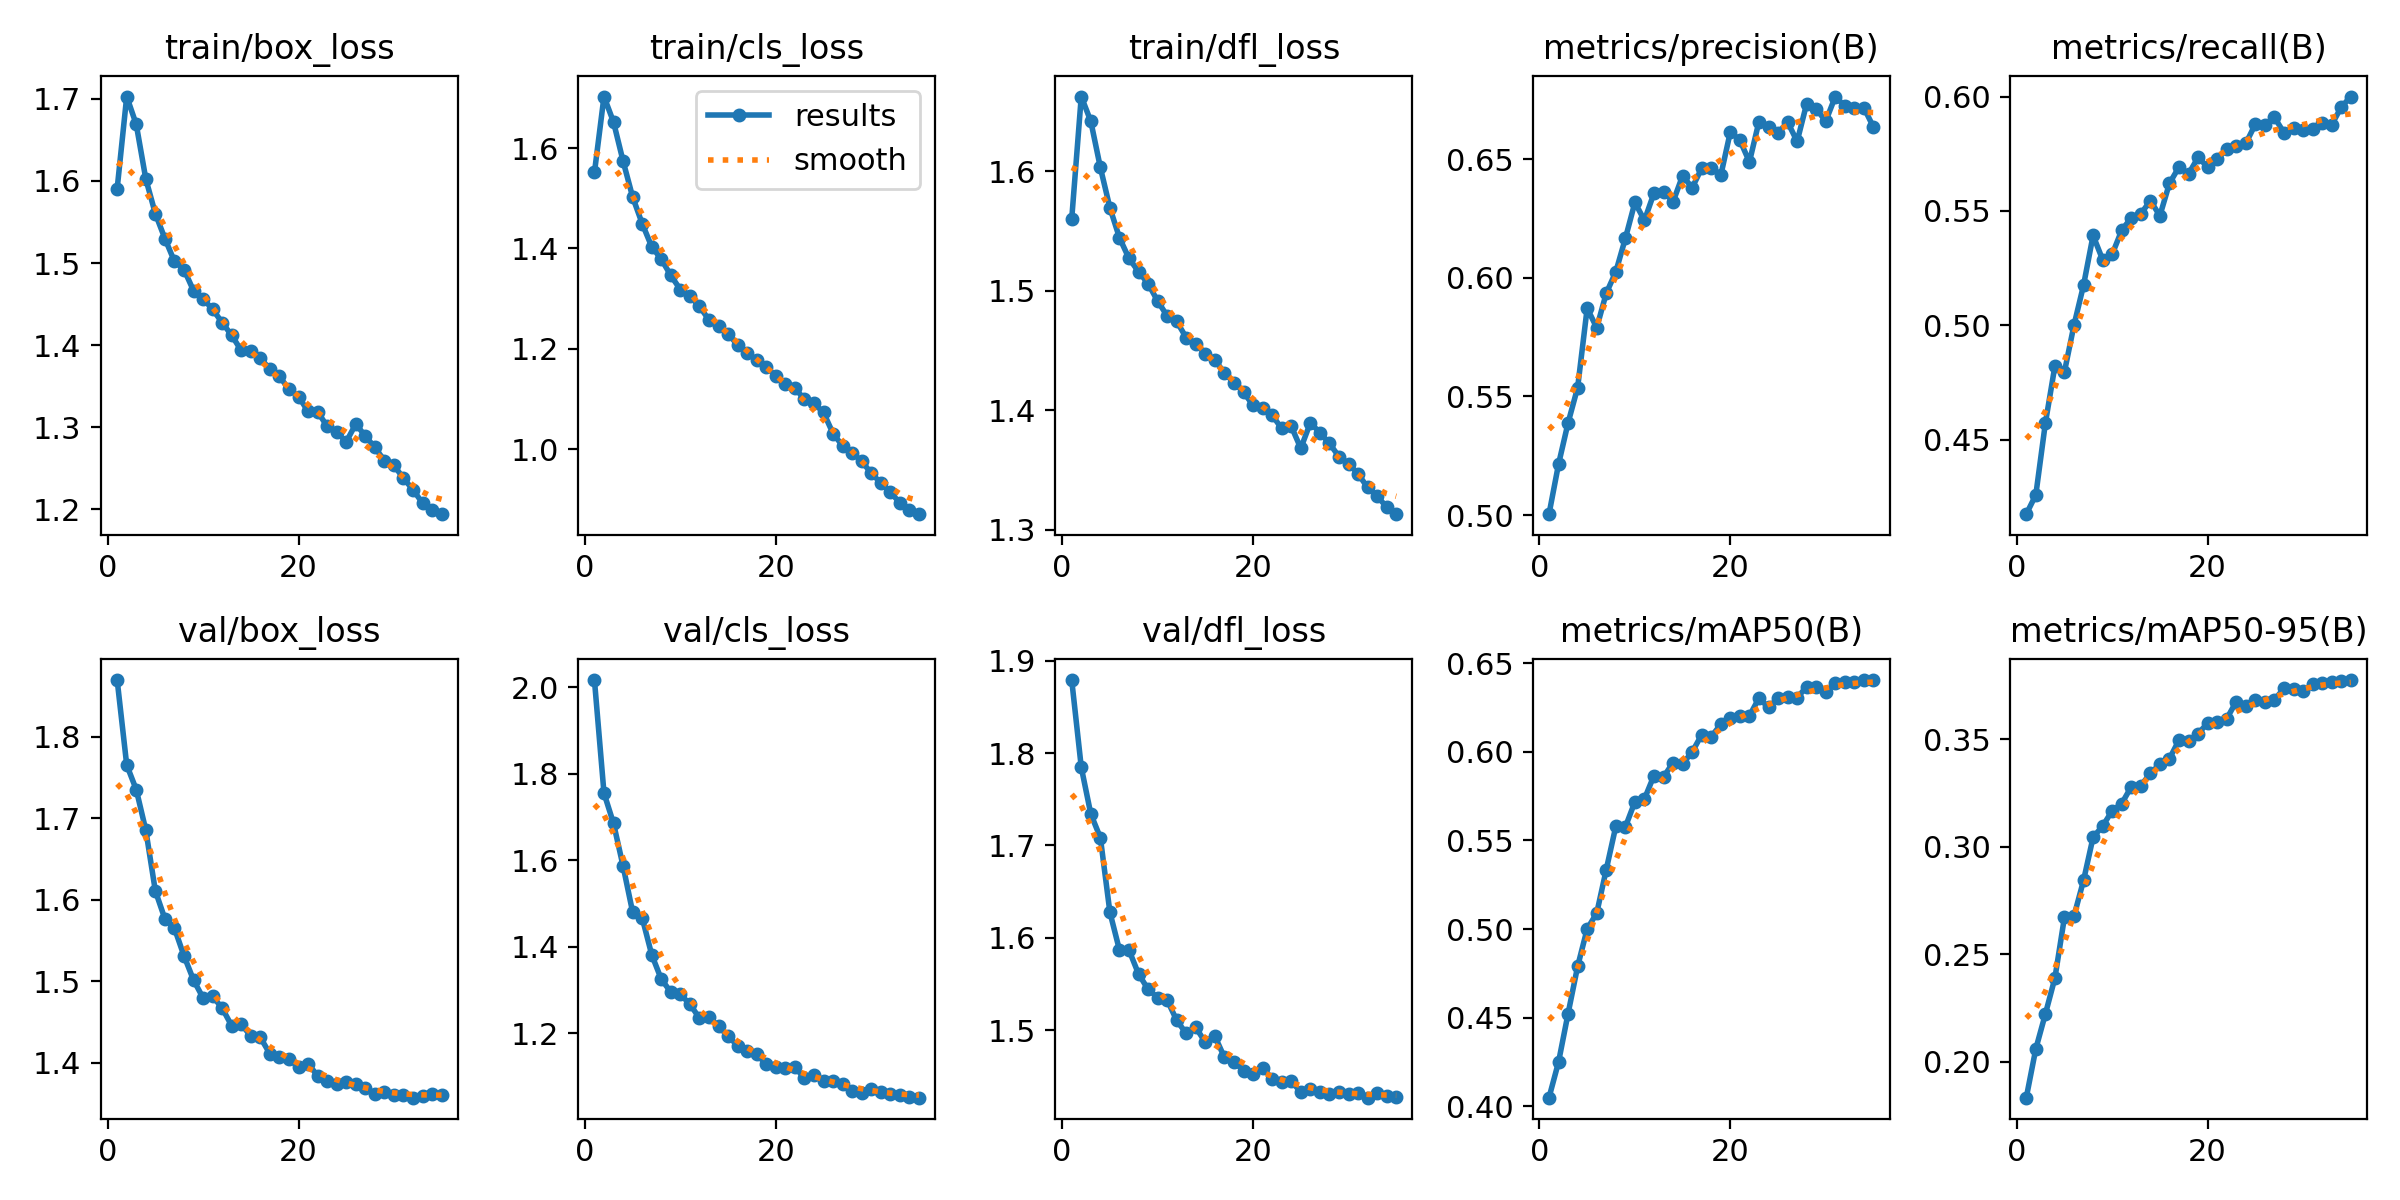

In [10]:
# Menampilkan grafik hasil training (loss, mAP, etc.)
display(Image(filename='YOLOv8m-Detection/train_results/results.png'))

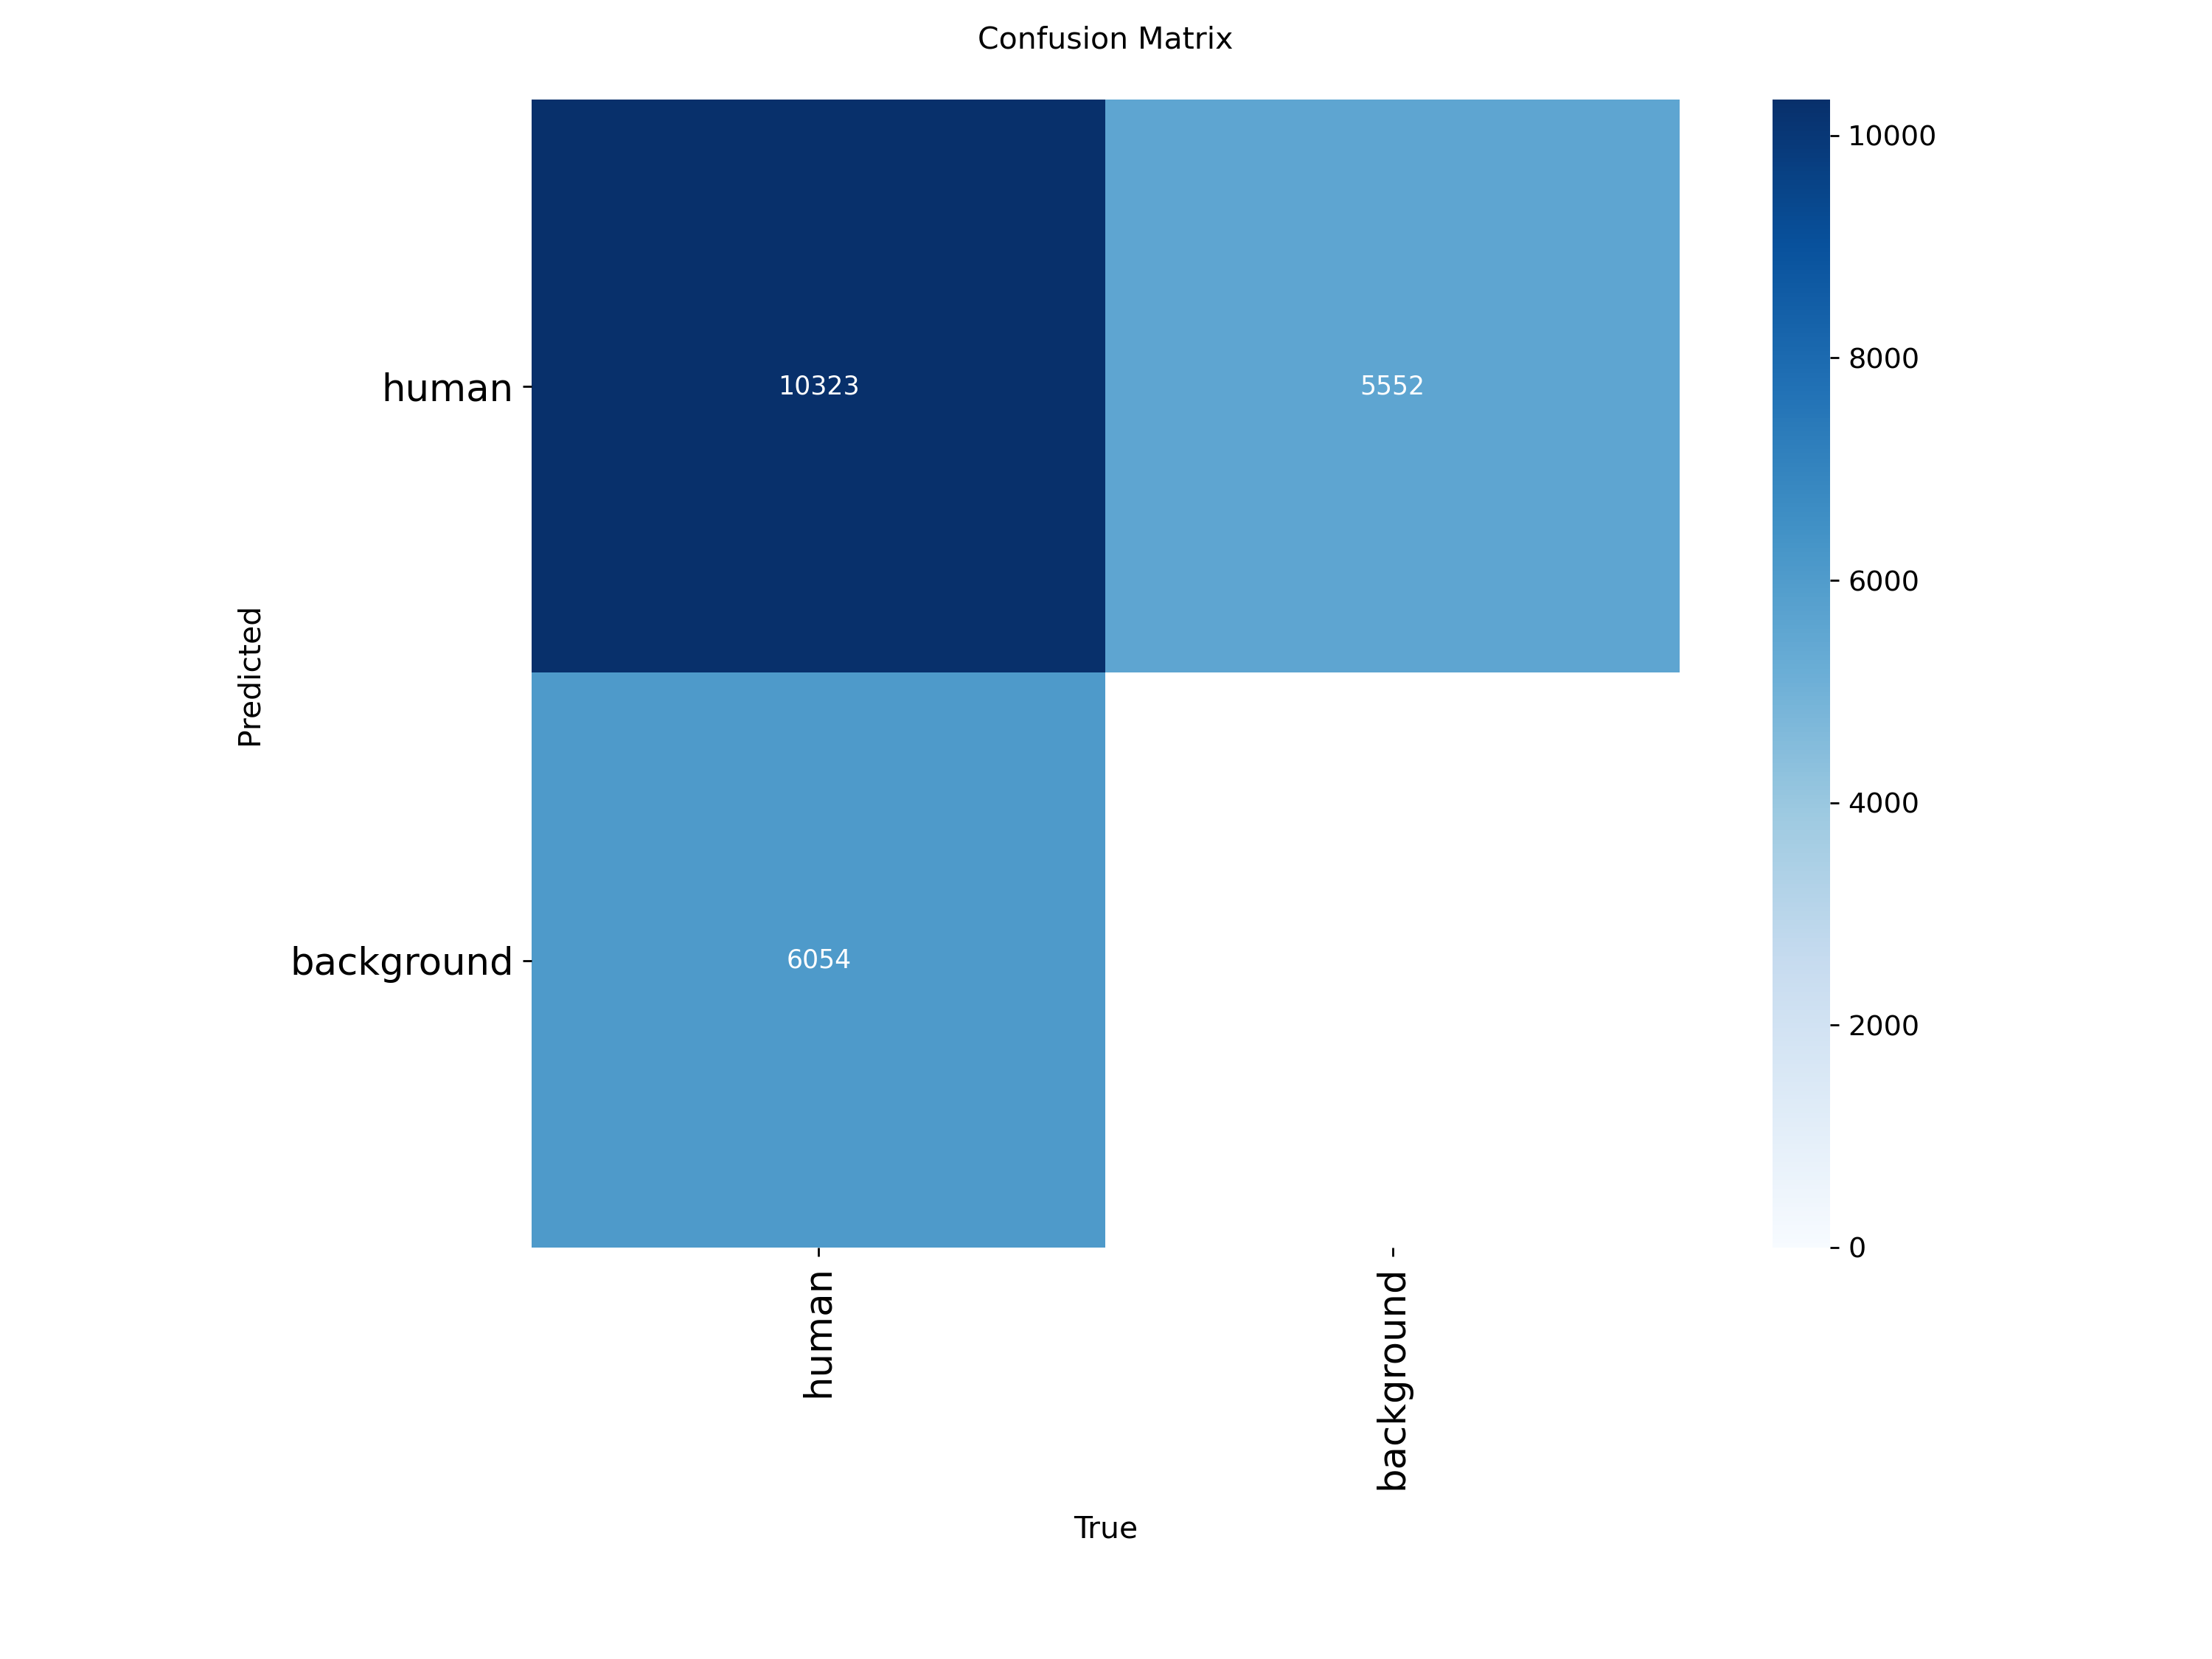

In [11]:
# Menampilkan confusion matrix
display(Image(filename='YOLOv8m-Detection/train_results/confusion_matrix.png'))

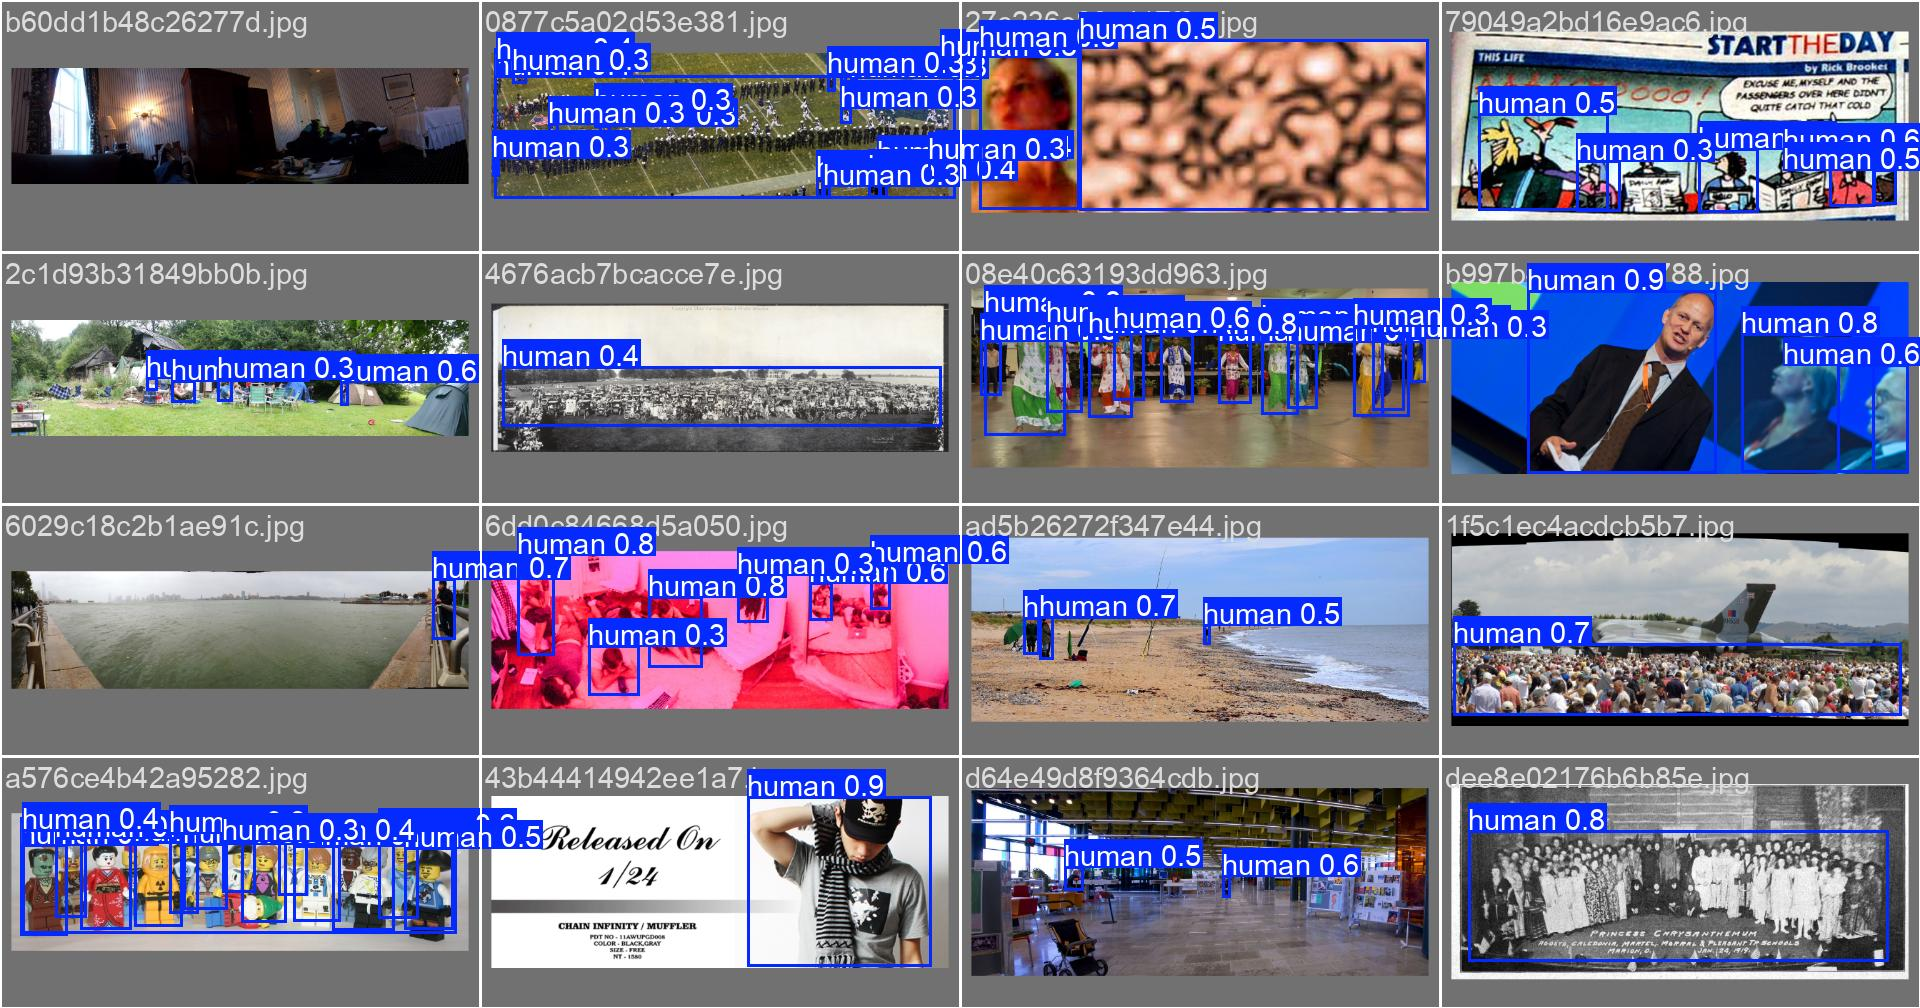

In [12]:
# Menampilkan hasil prediksi pada batch validasi pertama
display(Image(filename='YOLOv8m-Detection/train_results/val_batch0_pred.jpg'))

# 5. Uji Coba

In [13]:
# Load Model
best_model_path = "YOLOv8m-Detection/train_results/weights/best.pt"
loaded_model = YOLO(best_model_path)

In [14]:
# Dapatkan daftar gambar validasi
val_image_files = sorted(glob.glob(os.path.join(data_config['val'], '*.jpg')))
random_val_images = random.sample(val_image_files, 3)

Menjalankan prediksi pada 3 gambar acak dari validation set...

--- Prediksi untuk: 6046e7396ef7f5f7.jpg ---

image 1/1 /kaggle/input/human-dataset/images/val/6046e7396ef7f5f7.jpg: 448x640 1 human, 40.5ms
Speed: 2.1ms preprocess, 40.5ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)


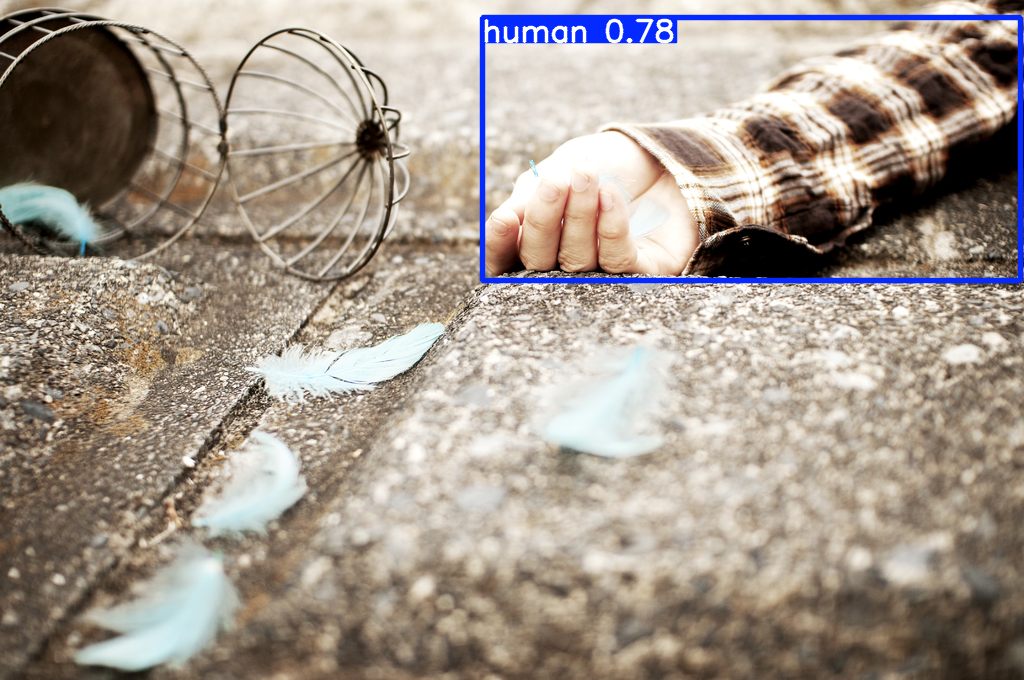


--- Prediksi untuk: 9827c0ef3bd805f7.jpg ---

image 1/1 /kaggle/input/human-dataset/images/val/9827c0ef3bd805f7.jpg: 448x640 2 humans, 12.9ms
Speed: 2.1ms preprocess, 12.9ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)


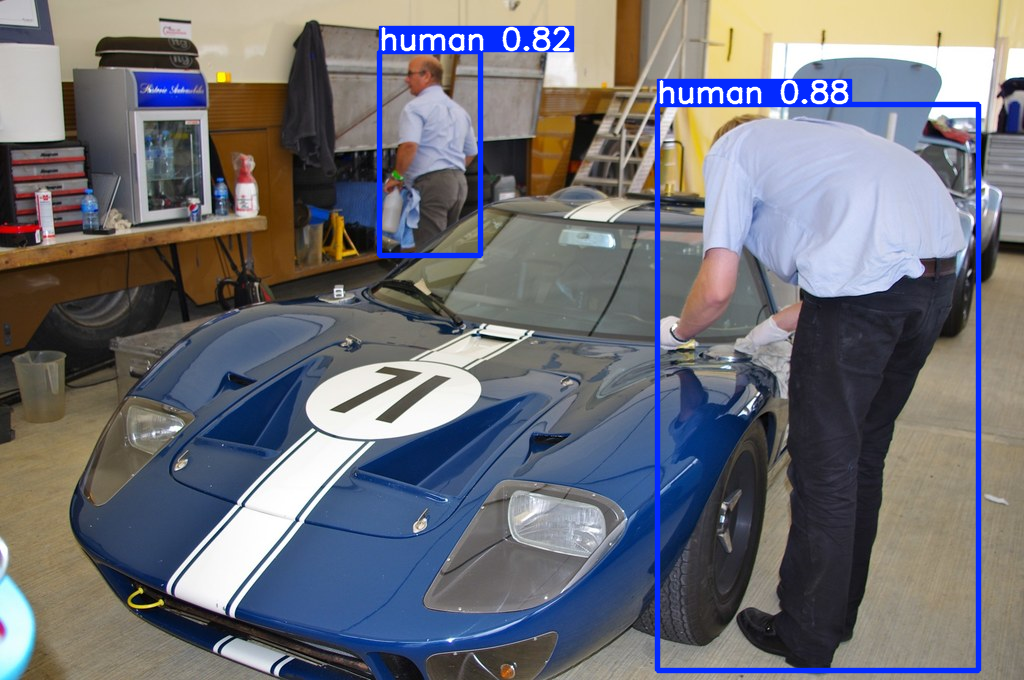


--- Prediksi untuk: e8cf920768334305.jpg ---

image 1/1 /kaggle/input/human-dataset/images/val/e8cf920768334305.jpg: 448x640 1 human, 12.8ms
Speed: 2.1ms preprocess, 12.8ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)


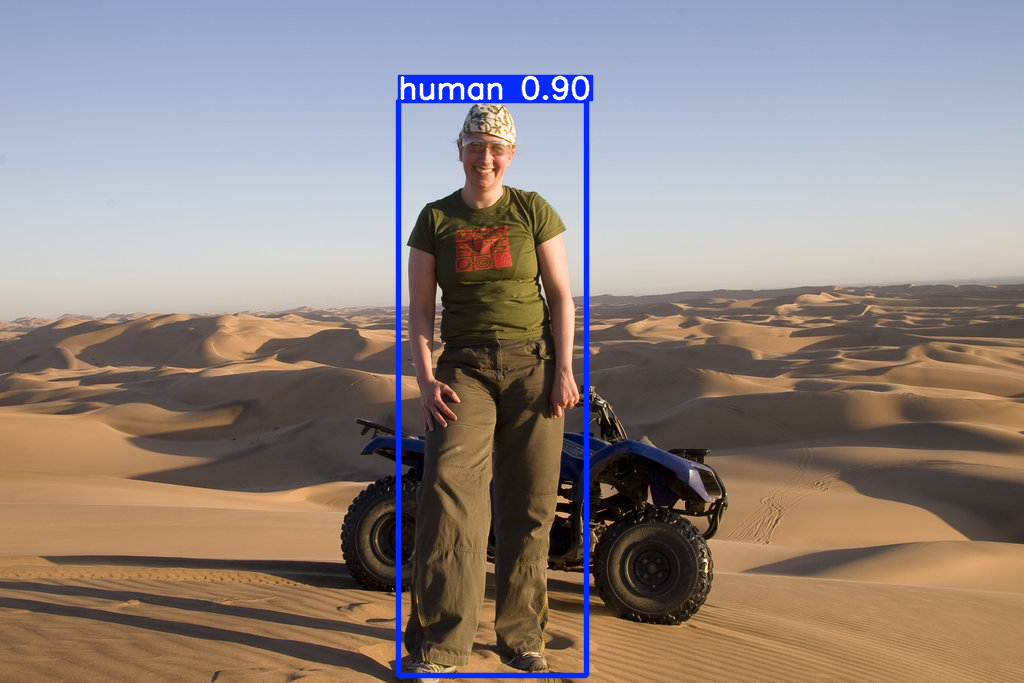

In [15]:
print("Menjalankan prediksi pada 3 gambar acak dari validation set...")

for image_path in random_val_images:
    print(f"\n--- Prediksi untuk: {os.path.basename(image_path)} ---")
    # Lakukan prediksi
    results = loaded_model.predict(source=image_path, save=False) 
    
    # Dapatkan gambar dengan hasil prediksi
    result_plot = results[0].plot() 
    result_plot_rgb = cv2.cvtColor(result_plot, cv2.COLOR_BGR2RGB)
    
    # Tampilkan gambar
    display(PILImage.fromarray(result_plot_rgb))

# 6. Evaluation Akhir & Save Model

In [16]:
# List nama kelas objek
class_names = data_config['names']

# Analisis metrik per kelas
class_metrics = pd.DataFrame(metrics.box.ap_class_index, columns=['class_index'])
class_metrics['precision'] = metrics.box.p
class_metrics['recall'] = metrics.box.r
class_metrics['map50'] = metrics.box.ap50
class_metrics['map95'] = metrics.box.ap

# Menambahkan nama kelas
class_metrics['class_name'] = class_metrics['class_index'].apply(lambda x: class_names[x])
class_metrics = class_metrics.drop(columns=['class_index'])

print("\nMetrics by classes:")
print(class_metrics)


Metrics by classes:
   precision    recall     map50     map95 class_name
0   0.667314  0.596104  0.640581  0.377915      human


In [17]:
# Menyimpan bobot model terbaik
best_model_path = os.path.join('YOLOv8m-Detection', 'train_results', 'weights', 'best.pt')
saved_model_path = "/kaggle/working/yolov8m_trained.pt"
shutil.copy(best_model_path, saved_model_path)

print(f"Model weights saved in: {saved_model_path}")

Model weights saved in: /kaggle/working/yolov8m_trained.pt
